In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [10]:
df = pd.read_csv("../../../Data/titanic_toy.csv")
df

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0
...,...,...,...,...
886,27.0,13.0000,0,0
887,19.0,30.0000,0,1
888,NaN,23.4500,3,0
889,26.0,NaN,0,1


In [11]:
df.isnull().mean() * 100

Age         19.865320
Fare         5.050505
Family       0.000000
Survived     0.000000
dtype: float64

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:,:-1],df.iloc[:,-1], test_size=0.2, random_state=42)

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

impute_trf = ColumnTransformer(transformers=[
    ("age", SimpleImputer(strategy='median'), ['Age']),
    ("fare", SimpleImputer(), ['Fare'])
],remainder='passthrough')

In [14]:
X_train_trf = impute_trf.fit_transform(X_train)
X_test_trf = impute_trf.transform(X_test)

In [15]:
imputed_data = pd.DataFrame()
imputed_data['Age'] = df['Age']
imputed_data['Age Mean'] = pd.DataFrame(X_train_trf, columns=X_train.columns)['Age']
imputed_data['Age Median'] = X_train['Age'].fillna(df['Age'].median())


imputed_data['Fare'] = df['Fare']
imputed_data['Fare Mean'] = pd.DataFrame(X_train_trf, columns=X_train.columns)['Fare']
imputed_data['Fare Median'] = X_train['Fare'].fillna(df['Fare'].median())
imputed_data

,Age,Age Mean,Age Median,Fare,Fare Mean,Fare Median
0,22.0,45.5,22.0,7.2500,28.5000,7.2500
1,38.0,23.0,38.0,71.2833,13.0000,71.2833
2,26.0,32.0,26.0,7.9250,7.9250,7.9250
3,35.0,26.0,35.0,53.1000,7.8542,53.1000
4,35.0,6.0,35.0,8.0500,31.2750,8.0500
...,...,...,...,...,...,...
886,27.0,NaN,NaN,13.0000,NaN,NaN
887,19.0,NaN,19.0,30.0000,NaN,30.0000
888,NaN,NaN,28.0,23.4500,NaN,23.4500
889,26.0,NaN,NaN,NaN,NaN,NaN


<Axes: xlabel='Age', ylabel='Density'>

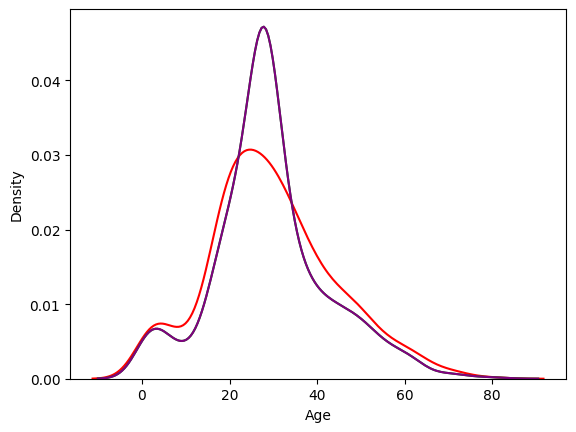

In [16]:
sns.kdeplot(data=imputed_data, x='Age',color='red')
sns.kdeplot(data=imputed_data, x='Age Mean',color='green')
sns.kdeplot(data=imputed_data, x='Age Median',color='purple')

<Axes: xlabel='Fare', ylabel='Density'>

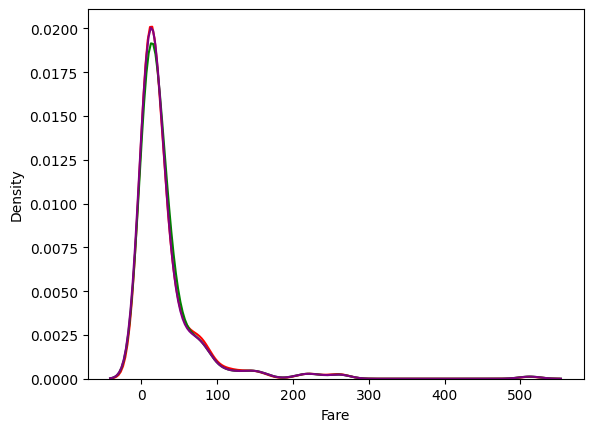

In [17]:
sns.kdeplot(data=imputed_data, x='Fare',color='red')
sns.kdeplot(data=imputed_data, x='Fare Mean',color='green')
sns.kdeplot(data=imputed_data, x='Fare Median',color='purple')

In [18]:
imputed_data.cov()

,Age,Age Mean,Age Median,Fare,Fare Mean,Fare Median
Age,211.019125,8.908604,210.251707,78.071438,32.623191,70.085411
Age Mean,8.908604,169.207310,11.874208,32.407980,60.700688,14.396273
Age Median,210.251707,11.874208,169.207310,63.938058,31.725372,59.731419
Fare,78.071438,32.407980,63.938058,2530.673077,112.899428,2761.031435
Fare Mean,32.623191,60.700688,31.725372,112.899428,2621.232375,3.158748
Fare Median,70.085411,14.396273,59.731419,2761.031435,3.158748,2636.918209


In [19]:
imputed_data.corr()

,Age,Age Mean,Age Median,Fare,Fare Mean,Fare Median
Age,1.000000,0.047040,1.000000,0.099481,0.049050,0.087238
Age Mean,0.047040,1.000000,0.070250,0.050401,0.091145,0.022358
Age Median,1.000000,0.070250,1.000000,0.093496,0.045402,0.089422
Fare,0.099481,0.050401,0.093496,1.000000,0.043985,1.000000
Fare Mean,0.049050,0.091145,0.045402,0.043985,1.000000,0.001187
Fare Median,0.087238,0.022358,0.089422,1.000000,0.001187,1.000000


<Axes: >

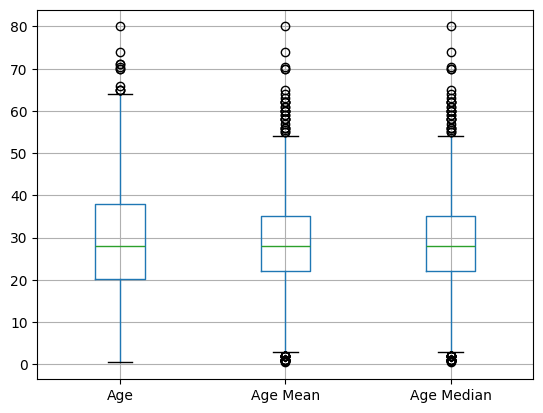

In [20]:
imputed_data.iloc[:,:3].boxplot()

<Axes: >

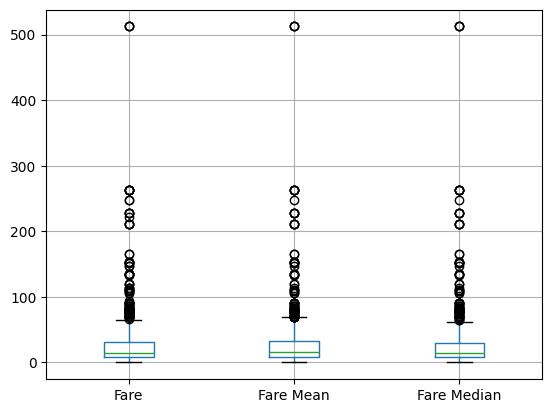

In [21]:
imputed_data.iloc[:,3:].boxplot()